<a href="https://colab.research.google.com/github/Gotte-sahithi/ML-Skill/blob/main/WEEK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


In [35]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv
Dataset loaded successfully!

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0  

In [36]:
# We are predicting Fare
target_col = "Fare"

In [37]:
drop_cols = [target_col]

feature_df = df.drop(
    columns=drop_cols
).select_dtypes(
    include=[np.number]
)


In [38]:
if "PassengerId" in feature_df.columns:
    feature_df = feature_df.drop(
        columns=["PassengerId"]
    )

In [39]:
feature_df = feature_df.fillna(
    feature_df.median()
)


In [40]:
X = feature_df.values

y = df[target_col].values.reshape(-1, 1)

print("\nFeatures used:")
print(feature_df.columns.tolist())

print("\nTarget:")
print(target_col)



Features used:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch']

Target:
Fare


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Training samples: 712
Testing samples: 179


In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [43]:
X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]


In [44]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape

    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta

        # Error
        error = y_pred - y

        # Loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        # Gradient
        gradient = (1 / m) * (X.T @ error)

        # Update weights
        theta = theta - lr * gradient

        if i % 100 == 0:
            print(
                f"Iteration {i:4d}  Loss = {loss:.4f}"
            )

    return theta, losses


In [45]:
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

Iteration    0  Loss = 1879.4520
Iteration  100  Loss = 980.1037
Iteration  200  Loss = 873.2391
Iteration  300  Loss = 856.6672
Iteration  400  Loss = 853.1479
Iteration  500  Loss = 852.1705
Iteration  600  Loss = 851.8524
Iteration  700  Loss = 851.7409
Iteration  800  Loss = 851.7006
Iteration  900  Loss = 851.6859


In [46]:
y_pred = X_test_b @ theta

In [47]:
mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n===================================")
print("GRADIENT DESCENT RESULTS")
print("===================================")

print("\nFinal Weights:")
print(theta.ravel())

print("\nMean Squared Error:", mse)

print("R2 Score:", r2)


GRADIENT DESCENT RESULTS

Final Weights:
[ 32.58486933   3.27378996 -28.41264919  -1.30816477   6.51755777
   8.52376503]

Mean Squared Error: 945.3049848063619
R2 Score: 0.3891127758341524


In [48]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

sk_pred = model.predict(
    X_test
)

sk_r2 = r2_score(
    y_test,
    sk_pred
)

print("\n===================================")
print("SKLEARN LINEAR REGRESSION")
print("===================================")

print(
    "Sklearn Linear Regression R2 Score:",
    sk_r2
)


SKLEARN LINEAR REGRESSION
Sklearn Linear Regression R2 Score: 0.3887849466265949


In [49]:
comparison = pd.DataFrame({

    "Actual Fare": y_test.flatten(),

    "Predicted Fare": y_pred.flatten()

})

print("\n===================================")
print("FIRST 10 PREDICTIONS")
print("===================================")

print(
    comparison.head(10)
)



FIRST 10 PREDICTIONS
   Actual Fare  Predicted Fare
0      15.2458       22.984188
1      10.5000       34.087632
2       7.9250        0.713479
3      33.0000       54.135233
4      11.2417       13.618714
5      78.8500       75.829258
6       7.7500        6.665663
7      18.0000       12.204291
8       7.7500        7.873308
9      26.2833       98.082505


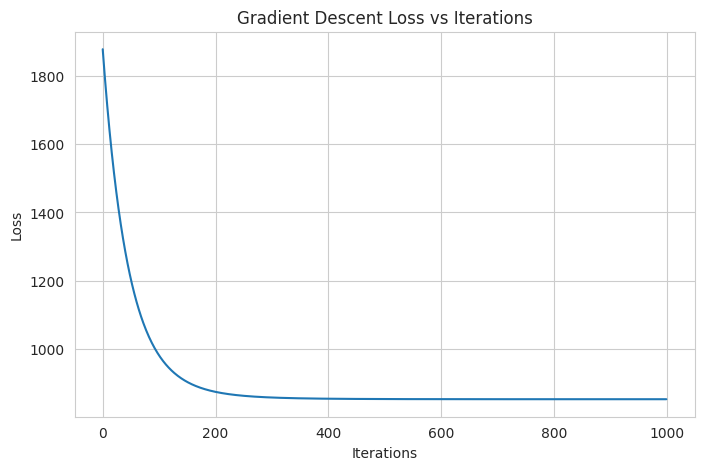

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.title(
    "Gradient Descent Loss vs Iterations"
)

plt.xlabel(
    "Iterations"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.show()


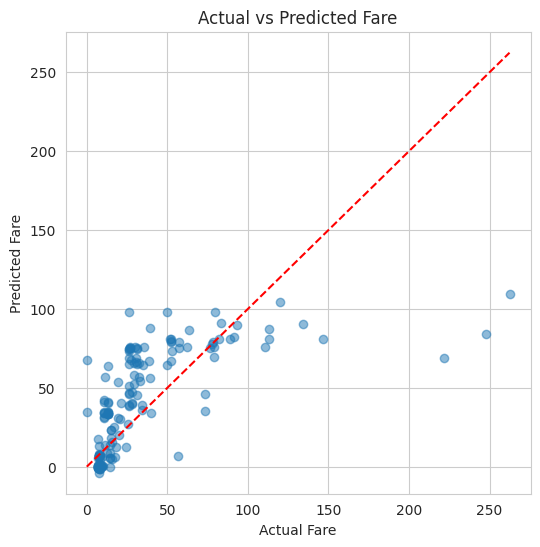

In [51]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title(
    "Actual vs Predicted Fare"
)

plt.xlabel(
    "Actual Fare"
)

plt.ylabel(
    "Predicted Fare"
)

plt.grid(True)

plt.show()

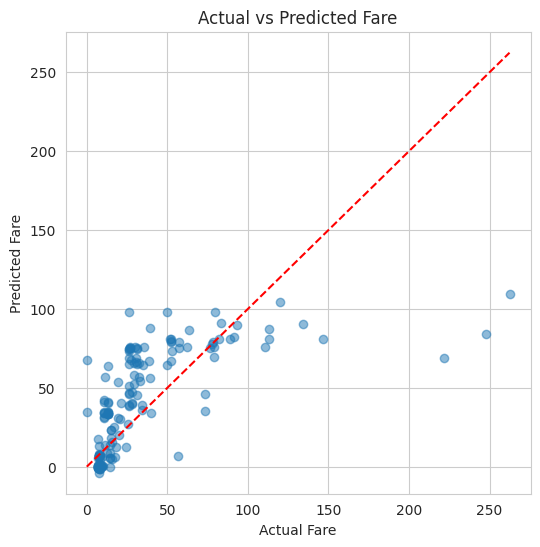


Graph saved as titanic_gradient_descent_predictions.png


In [52]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title(
    "Actual vs Predicted Fare"
)

plt.xlabel(
    "Actual Fare"
)

plt.ylabel(
    "Predicted Fare"
)

plt.grid(True)

plt.savefig(
    "titanic_gradient_descent_predictions.png",
    dpi=300
)

plt.show()

print(
    "\nGraph saved as titanic_gradient_descent_predictions.png"
)

In [53]:
comparison.to_csv(
    "titanic_fare_predictions.csv",
    index=False
)

print(
    "Prediction results saved as titanic_fare_predictions.csv"
)

Prediction results saved as titanic_fare_predictions.csv
